In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import joblib
import time

In [4]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset_2.csv')
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']

In [5]:
df

,Phsar_Chas_nearest,Royal_Palace_3_5km,address_line_2,address_locality,h_id,h_id_price_min,n_atm_in_1km,n_atm_in_2km_to_3km,n_atm_in_3km_to_5km,nearest_resturant,price_per_m2
0,0.0,1.0,14.0,4.0,427.0,1880.12,0.0,35.0,524.0,0.0,5442.34
1,0.0,0.0,77.0,4.0,459.0,2364.28,42.0,250.0,210.0,0.0,4226.76
2,0.0,0.0,10.0,0.0,471.0,2070.16,30.0,213.0,407.0,3.0,3899.11
3,0.0,1.0,83.0,11.0,452.0,2275.51,10.0,112.0,608.0,0.0,3813.96
4,0.0,1.0,77.0,4.0,460.0,2235.35,15.0,336.0,331.0,0.0,3580.15
...,...,...,...,...,...,...,...,...,...,...,...
4267,0.0,0.0,0.0,2.0,822.0,557.25,0.0,0.0,0.0,0.0,729.57
4268,0.0,0.0,66.0,2.0,378.0,570.28,0.0,0.0,0.0,0.0,571.98
4269,0.0,0.0,59.0,6.0,596.0,190.72,0.0,0.0,0.0,0.0,260.40
4270,0.0,0.0,26.0,8.0,653.0,892.05,0.0,0.0,0.0,0.0,1093.83


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [5]:
svr_pipe = make_pipeline(
    StandardScaler(),
    SVR()
)

In [6]:
param_grid = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.5, 1],
    'svr__kernel': ['linear', 'rbf', 'poly'],
    'svr__gamma': ['scale', 'auto'],
    'svr__degree': [2, 3]
}

In [7]:
grid_search = GridSearchCV(
    estimator=svr_pipe,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=3
)

In [8]:
print("Starting SVR hyperparameter tuning...")
start_time = time.time()

grid_search.fit(X_train_main, y_train_main)

print(f"Tuning completed in {time.time()-start_time:.2f} seconds")
print("Best parameters found:")
print(grid_search.best_params_)

Starting SVR hyperparameter tuning...
Fitting 3 folds for each of 192 candidates, totalling 576 fits
Tuning completed in 36.62 seconds
Best parameters found:
{'svr__C': 100, 'svr__degree': 2, 'svr__epsilon': 1, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}


In [9]:
best_svr = grid_search.best_estimator_

In [10]:
y_pred_train = best_svr.predict(X_train)
y_pred_test = best_svr.predict(X_test)

In [11]:
def print_metrics(y_true, y_pred, set_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

    print(f"\n{set_name} Set Metrics (SVR):")
    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    if set_name == "Test":
        print(f"Avg Price: {y_true.mean():.2f}")
    return mae

In [12]:
train_mae = print_metrics(y_train, y_pred_train, "Train")
test_mae = print_metrics(y_test, y_pred_test, "Test")


Train Set Metrics (SVR):
R²: 0.8815
MAE: 250.60
MAPE: 21.62%

Test Set Metrics (SVR):
R²: 0.9009
MAE: 255.82
MAPE: 20.98%
Avg Price: 1296.68


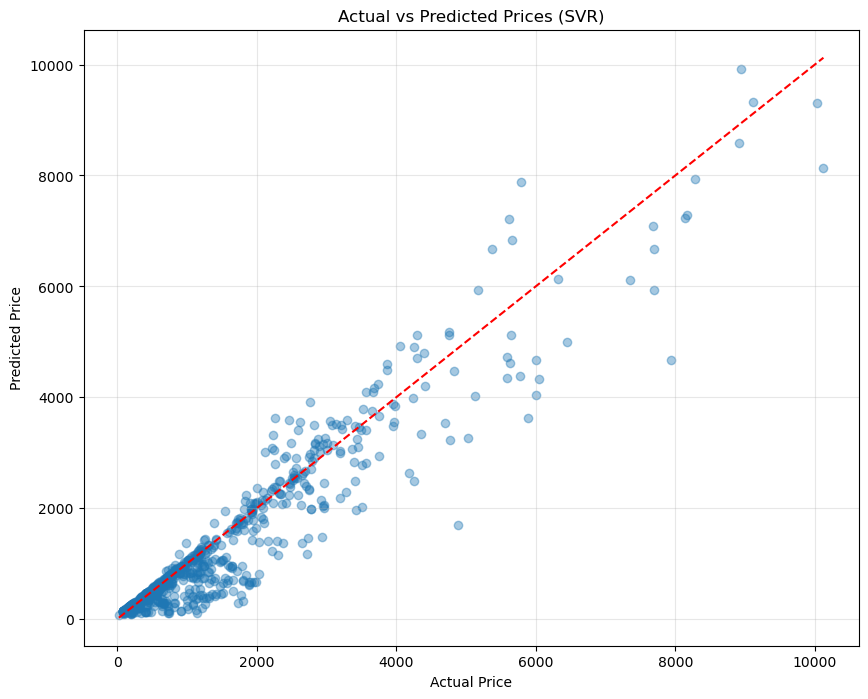

In [13]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (SVR)")
plt.grid(alpha=0.3)
plt.savefig("svr_actual_vs_predicted.png", dpi=300)
plt.show()

In [14]:
def calculate_metrics(model, X_train, y_train, X_test, y_test, cv_folds=5):
    # Train set predictions
    y_pred_train = model.predict(X_train)
    
    # Test set predictions
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics for test set
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mape = np.mean(np.abs((y_test - y_pred_test) / np.maximum(y_test, 1))) * 100
    
    # Calculate train R2
    train_r2 = r2_score(y_train, y_pred_train)
    
    
    # Create metrics dataframe
    metrics_df = pd.DataFrame({
        'Metric': ['R2(Test)', 'MAE', 'RMSE', 'MAPE', 'Train R2'],
        'Value': [test_r2, test_mae, test_rmse, test_mape, train_r2]
    })
    
    return metrics_df.round(4)

In [15]:
metrics_df = calculate_metrics(best_svr, X_train, y_train, X_test, y_test)
print("\nModel Performance Metrics:")
print("="*50)
print(metrics_df.to_string(index=False))
print("="*50)


Model Performance Metrics:
  Metric    Value
R2(Test)   0.9009
     MAE 255.8174
    RMSE 476.3687
    MAPE  20.9838
Train R2   0.8815


In [16]:
# joblib.dump(best_svr, "../../../models/svr/svr_model_label_v3.joblib")